In [ ]:
import numpy as np
from farm.plant import Plant
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel
from farm.functions import evolved_calc_yield, plot_lin_regression
import pandas as pd
from pandas import DataFrame
from numpy import zeros
import matplotlib.pyplot as plt

In [ ]:
# Fit Y_MAX regression from Kenya Seed Co. data (yield in kg/acre vs. days-to-maturity).
# Passing m and b explicitly avoids the internal /1000 unit issue in evolved_calc_yield.
_yd = pd.read_csv('data/Yields/hybrid_yields_verified.csv')
_, _m_yield, _b_yield = plot_lin_regression(
    _yd.verified_days_to_maturity,
    _yd.verified_yield_kg_acre,
    'verified_days_to_maturity', 'verified_yield_kg_acre', _yd,
    positive=False
)

## Model definitions

In [ ]:
class Tree(Plant):
    """
    Simple tree component for agroforestry modeling.

    canopy_cover : fraction of plot area covered by tree canopy [0-1].
                   Scales all plot-level tree fluxes (T, shade, HR).
                   Typical parkland agroforestry: 0.10 - 0.30.
    phenology    : "evergreen" — constant kc and LAI throughout the year (default).
                   "reverse"   — Faidherbia albida style: kc=0 and LAI=0 during the
                                 crop growing season. No competition, no shade during
                                 crop season; HR still operates via deep roots.
                                 Ref: Bayala & Prieto (2020), Garrity et al. (2010).
    """
    def __init__(self, kc=1.0, LAI_max=2.0, canopy_cover=0.2,
                 phenology="evergreen", *args, **kwargs):
        self.kc = kc
        self.LAI_max = LAI_max
        self.canopy_cover = canopy_cover
        self.phenology = phenology
        super().__init__(*args, **kwargs)

    def calc_LAI(self):
        return self.LAI_max

    def calc_I(self, LAI=None, int_efficiency=0.5):
        LAI_use = self.LAI if LAI is None else LAI
        return LAI_use * int_efficiency

    def calc_T(self, s, LAI=None, kc=None):
        kc_use = self.kc if kc is None else kc
        if s >= self.s_star:
            return kc_use * self.T_MAX
        elif s >= self.sw:
            return (s - self.sw) / (self.s_star - self.sw) * (kc_use * self.T_MAX)
        else:
            return 0.0

In [18]:
def shade_factor(LAI_tree, k_shade=0.3):
    """
    Fraction of incoming energy available for evaporation/transpiration.

    LAI_tree : tree leaf area index
    k_shade  : shading efficiency [−]

    Returns value in (0, 1].
    """
    return np.exp(-k_shade * LAI_tree)


In [ ]:
class TreeCropModel:
    def __init__(self, soil=None, climate=None, crop=None, tree=None, hr_max=0.5):
        """
        hr_max : maximum hydraulic redistribution rate [mm/day] at full canopy cover.
                 Scaled internally by tree.canopy_cover. Literature: 0.3-1.0 mm/night
                 (Burgess et al. 2001, Caldwell et al. 1991).
        """
        self.soil = soil
        self.crop = crop
        self.tree = tree
        self.climate = climate
        self.hr_max = hr_max

        self.nZr_top = soil.set_nZr(self.crop)

        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.tree.Zr - self.crop.Zr, 0.0)
        self.nZr_deep_full = soil.set_nZr(tmp) if tmp.Zr > 0 else 0.0

    def pre_allocate(self):
        n = self.n_days
        self.R          = zeros(n)
        self.s_top      = zeros(n + 1)
        self.s_deep     = zeros(n + 1)
        self.ET         = zeros(n)
        self.I          = zeros(n)
        self.E          = zeros(n)
        self.T          = zeros(n)
        self.L          = zeros(n)
        self.Q          = zeros(n)
        self.HR         = zeros(n)   # hydraulic redistribution flux [mm/day]
        self.kc_tree    = zeros(n)   # effective tree kc (0 during crop season for reverse phenology)
        self.dos        = zeros(n)
        self.dsdt       = zeros(n)
        self.LAI        = zeros(n)
        self.kc         = zeros(n)
        self.stress     = zeros(n)
        self.T_tree     = zeros(n)
        self.ET_crop    = zeros(n)
        self.ET_tree    = zeros(n)
        self.T_tree_top = zeros(n)
        self.T_tree_deep= zeros(n)

    def run(self, do_output=False, s0=0.3, planting_date=100,
            t_before=60, t_after=7,
            deep_roots=True, shade_on=True, hr_on=True):
        """
        deep_roots : trees access the deep layer (default True)
        shade_on   : tree canopy shades crop E and T (default True)
        hr_on      : hydraulic redistribution active (default True)
                     Trees passively lift water from deep to top when s_deep > s_top.
        """
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()
        self.nZr_deep = self.nZr_deep_full if deep_roots else 0.0

        self.doy_start = self.planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t] - 1]
        self.doy = doy

        # Top layer: standard pre-season soil moisture (same as CropModel default).
        # Deep layer: field capacity — represents water accumulated by pre-season rains
        # at depth, where direct evaporation cannot reach. This is the physical reservoir
        # that makes hydraulic redistribution possible in semi-arid parkland agroforestry.
        self.s_top[0]  = s0
        self.s_deep[0] = self.soil.sfc
        dos = 0
        planted = False

        for t in range(self.n_days):
            if self.doy[t] == self.planting_date:
                planted = True
            if planted:
                dos += 1

            self.dos[t] = dos
            self.kc[t]  = self.crop.calc_kc(dos)
            self.LAI[t] = self.crop.calc_LAI(self.kc[t])

            # --- Tree phenology: kc and LAI for this timestep
            # "reverse" (Faidherbia): leafless during crop growing season →
            #   no transpiration, no shade, no interception.
            #   HR still operates because roots are always present.
            in_crop_season = planted and 0 < dos <= self.crop.lgp
            if self.tree.phenology == "reverse" and in_crop_season:
                tree_kc  = 0.0
                tree_LAI = 0.0
            else:
                tree_kc  = self.tree.kc
                tree_LAI = self.tree.calc_LAI()
            self.kc_tree[t] = tree_kc

            self.Q[t] = self.soil.calc_Q(self.s_top[t], units="mm/day")
            self.I[t] = min(self.crop.calc_I(self.LAI[t]), self.R[t])
            rainfall  = max(self.R[t] - self.I[t], 0.0)

            s_top  = self.s_top[t]
            s_deep = self.s_deep[t]

            # --- Rainfall input to top layer
            s_top += (rainfall - self.Q[t]) / self.nZr_top

            # --- Percolation: top → deep above field capacity
            if self.nZr_deep > 0 and s_top > self.soil.sfc:
                perc_mm = 0.5 * (s_top - self.soil.sfc) * self.nZr_top
                s_top  -= perc_mm / self.nZr_top
                s_deep += perc_mm / self.nZr_deep

            # --- Saturation overflow
            if s_top > 1.0:
                excess_mm = (s_top - 1.0) * self.nZr_top
                s_top = 1.0
                if self.nZr_deep > 0:
                    s_deep += excess_mm / self.nZr_deep
                else:
                    self.L[t] += excess_mm

            # --- Hydraulic redistribution: deep → top when s_deep > s_top
            # Trees passively lift water along a water potential gradient overnight.
            # Rate scales with canopy_cover; operates regardless of phenology mode
            # because tree roots are always present.
            # Ref: Caldwell et al. (1991), Burgess et al. (2001)
            if hr_on and self.nZr_deep > 0 and s_deep > s_top:
                hr_flux = min(
                    self.hr_max * self.tree.canopy_cover * (s_deep - s_top),
                    s_deep * self.nZr_deep,
                    (1.0 - s_top) * self.nZr_top
                )
                s_top  += hr_flux / self.nZr_top
                s_deep -= hr_flux / self.nZr_deep
                self.HR[t] = hr_flux

            # --- Tree transpiration (scaled by canopy_cover; uses phenology-aware kc)
            T_tree_canopy_pot  = self.tree.calc_T(1.0,              kc=tree_kc) * self.tree.canopy_cover
            T_tree_top_supply  = self.tree.calc_T(max(s_top,  0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_deep_supply = self.tree.calc_T(max(s_deep, 0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_soil_supply = T_tree_top_supply + T_tree_deep_supply

            T_tree_total_pot = min(T_tree_canopy_pot, T_tree_soil_supply)

            if T_tree_soil_supply > 0:
                frac_top  = T_tree_top_supply  / T_tree_soil_supply
                frac_deep = T_tree_deep_supply / T_tree_soil_supply
            else:
                frac_top = frac_deep = 0.0

            T_tree_top_pot  = frac_top  * T_tree_total_pot
            T_tree_deep_pot = frac_deep * T_tree_total_pot

            # --- Crop + soil evaporation (shade uses phenology-aware LAI)
            s_eff = max(s_top, 0.0)
            T_crop_pot = self.crop.calc_T(s_eff, LAI=self.LAI[t])
            E_pot      = self.climate.calc_E(s_eff, LAI=self.LAI[t], sh=self.soil.sh)
            sf = shade_factor(tree_LAI * self.tree.canopy_cover) if shade_on else 1.0
            T_crop_pot *= sf
            E_pot      *= sf

            # --- Top-layer allocation (ration when demand > supply)
            demand_top    = T_tree_top_pot + T_crop_pot + E_pot
            available_top = s_top * self.nZr_top
            if demand_top <= available_top:
                T_tree_shallow = T_tree_top_pot
                T_crop_actual  = T_crop_pot
                E_actual       = E_pot
            else:
                scale = available_top / demand_top if demand_top > 0 else 0.0
                T_tree_shallow = T_tree_top_pot * scale
                T_crop_actual  = T_crop_pot     * scale
                E_actual       = E_pot          * scale
            s_top -= (T_tree_shallow + T_crop_actual + E_actual) / self.nZr_top

            # --- Deep-layer tree uptake
            T_tree_deep = 0.0
            if T_tree_deep_pot > 0 and self.nZr_deep > 0:
                T_tree_deep = min(T_tree_deep_pot, s_deep * self.nZr_deep)
                s_deep -= T_tree_deep / self.nZr_deep

            T_tree_actual = T_tree_shallow + T_tree_deep

            # --- Save fluxes
            self.T_tree[t]      = T_tree_actual
            self.T[t]           = T_crop_actual
            self.E[t]           = E_actual
            self.ET_crop[t]     = T_crop_actual + E_actual
            self.ET_tree[t]     = T_tree_actual
            self.ET[t]          = self.ET_crop[t] + self.ET_tree[t]
            self.T_tree_top[t]  = T_tree_shallow
            self.T_tree_deep[t] = T_tree_deep
            self.stress[t]      = self.crop.calc_stress(max(s_top, 0.0))

            # --- Deep overflow to leakage
            if s_deep > 1.0:
                self.L[t] += (s_deep - 1.0) * self.nZr_deep
                s_deep = 1.0

            self.s_top[t+1]  = max(s_top,  0.0)
            self.s_deep[t+1] = max(s_deep, 0.0)
            total_now  = self.s_top[t]   * self.nZr_top + self.s_deep[t]   * self.nZr_deep
            total_next = self.s_top[t+1] * self.nZr_top + self.s_deep[t+1] * self.nZr_deep
            self.dsdt[t] = total_next - total_now

        if do_output:
            return self.output()

    def output(self):
        return DataFrame({
            "kc":         self.kc,
            "kc_tree":    self.kc_tree,
            "LAI":        self.LAI,
            "stress":     self.stress,
            "R":          self.R,
            "s_top":      self.s_top[:-1],
            "s_deep":     self.s_deep[:-1],
            "I":          self.I,
            "E":          self.E,
            "T_crop":     self.T,
            "T_tree":     self.T_tree,
            "ET_crop":    self.ET_crop,
            "ET_tree":    self.ET_tree,
            "ET":         self.ET,
            "HR":         self.HR,
            "L":          self.L,
            "dsdt":       self.dsdt,
            "dos":        self.dos,
            "doy":        self.doy,
            "T_tree_top": self.T_tree_top,
            "T_tree_deep":self.T_tree_deep,
        })

In [ ]:
def run_one_season(model_cls, soil_cls, crop_cls, climate_obj, *,
                   texture="loam", lgp=180,
                   planting_date=100, t_before=60, t_after=7, s0=0.3,
                   tree_params=None):

    soil = soil_cls(texture=texture)
    crop = crop_cls(soil=soil)
    crop.lgp = lgp

    if tree_params is None:
        soil.set_nZr(crop)
        model = model_cls(crop=crop, climate=climate_obj, soil=soil)
    else:
        tree = Tree(soil=soil, **tree_params)
        model = model_cls(crop=crop, tree=tree, climate=climate_obj, soil=soil)

    model.run(s0=s0, planting_date=planting_date, t_before=t_before, t_after=t_after)
    return crop, model.output()


def season_metrics(crop, df, lgp):
    s_use = df["s_top"].values if "s_top" in df.columns else df["s"].values
    y_max = evolved_calc_yield(dtm=lgp, m=_m_yield, b=_b_yield)
    avg_stress, dyn_stress, yld = crop.calc_dstress(
        s=s_use, stress=df["stress"].values, Y_MAX=y_max
    )
    return avg_stress, dyn_stress, yld, df["R"].sum()


def simulate_systems(n_sims, *, lgp=180, texture="loam", seed=123,
                     tree_params=None):
    rng = np.random.default_rng(seed)
    rows_mono, rows_tree = [], []
    outputs_mono, outputs_tree = [], []

    if tree_params is None:
        tree_params = dict(
            Zr=1500,
            T_MAX=5.0,
            sw_MPa=-2.0,
            s_star_MPa=-0.1,
            kc=1.0,
            canopy_cover=0.2,
        )

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate = Climate()

        crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp)
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_mono.append(out_m)

        crop_t, out_t = run_one_season(TreeCropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp,
                                       tree_params=tree_params)
        a, d, y, rf = season_metrics(crop_t, out_t, lgp)
        rows_tree.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_tree.append(out_t)

    return pd.DataFrame(rows_mono), pd.DataFrame(rows_tree), outputs_mono, outputs_tree

## Single-season diagnostic

In [ ]:
np.random.seed(42)
climate = Climate()

# --- Monoculture
crop_m, out_m = run_one_season(
    CropModel, Soil, Crop, climate,
    texture="loam", lgp=180
)

# --- Tree–crop: evergreen (constant kc, shade, and competition all season)
tp_evergreen = dict(
    Zr=1500, T_MAX=5.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, phenology="evergreen",
)
crop_e, out_e = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180, tree_params=tp_evergreen
)

# --- Tree–crop: reverse phenology (Faidherbia albida)
#     kc=0 and LAI=0 during crop season → no competition, no shade.
#     HR still operates: deep roots lift water to the crop zone.
tree_params = dict(
    Zr=1500, T_MAX=5.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, phenology="reverse",
)
crop_t, out_t = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180, tree_params=tree_params
)

In [ ]:
plt.figure(figsize=(9, 4))

plt.plot(out_m["stress"], label="Monoculture", lw=2)
plt.plot(out_e["stress"], label="Tree–crop (evergreen)", lw=2, linestyle="--")
plt.plot(out_t["stress"], label="Tree–crop (Faidherbia, reverse)", lw=2, linestyle=":")

plt.xlabel("Day")
plt.ylabel("Crop water stress")
plt.legend()
plt.show()

_, d_m, y_m, rf = season_metrics(crop_m, out_m, 180)
_, d_e, y_e, _  = season_metrics(crop_e, out_e, 180)
_, d_t, y_t, _  = season_metrics(crop_t, out_t, 180)
print(f"Seasonal RF: {rf:.0f} mm\n")
print(f"{'':20s} {'Mono':>7} {'Evgrn':>7} {'Faidherbia':>11}")
print(f"{'Dyn stress':20s} {d_m:>7.3f} {d_e:>7.3f} {d_t:>11.3f}")
print(f"{'Yield (kg/ha)':20s} {y_m:>7.0f} {y_e:>7.0f} {y_t:>11.0f}")
print(f"{'HR total (mm)':20s} {'—':>7} {out_e['HR'].sum():>7.2f} {out_t['HR'].sum():>11.2f}")
print(f"{'delta stress':20s} {'—':>7} {d_e-d_m:>+7.3f} {d_t-d_m:>+11.3f}")

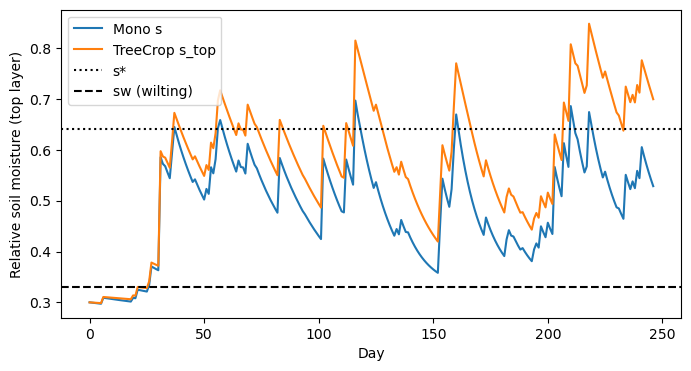

In [143]:
plt.figure(figsize=(8,4))

# Mono (single bucket)
plt.plot(out_m["s"], label="Mono s")

# Agroforestry (top layer only)
plt.plot(out_t["s_top"], label="TreeCrop s_top")

plt.axhline(crop.s_star, color="k", linestyle=":", label="s*")
plt.axhline(crop.sw, color="k", linestyle="--", label="sw (wilting)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture (top layer)")

plt.legend()
plt.show()


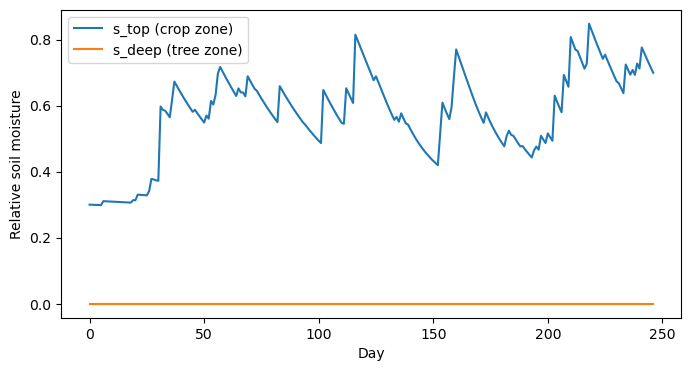

In [52]:
plt.figure(figsize=(8,4))

plt.plot(out_t["s_top"], label="s_top (crop zone)")
plt.plot(out_t["s_deep"], label="s_deep (tree zone)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture")
plt.legend()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: cumulative stress over time — divergence shows facilitation accumulating
ax = axes[0]
ax.plot(out_m["stress"].cumsum(), label="Monoculture", lw=2)
ax.plot(out_e["stress"].cumsum(), label="Evergreen", lw=2, linestyle="--")
ax.plot(out_t["stress"].cumsum(), label="Faidherbia", lw=2, linestyle=":")
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative stress")
ax.legend(fontsize=9)
ax.set_title("Cumulative stress")

# Right: daily stress DELTA (TreeCrop − Mono), smoothed
ax = axes[1]
delta_e = (out_e["stress"] - out_m["stress"]).rolling(7, center=True).mean()
delta_t = (out_t["stress"] - out_m["stress"]).rolling(7, center=True).mean()
ax.plot(delta_e, label="Evergreen − Mono", lw=2, linestyle="--")
ax.plot(delta_t, label="Faidherbia − Mono", lw=2, linestyle=":")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Day")
ax.set_ylabel("Δ stress (tree − mono),  7-day rolling mean")
ax.legend(fontsize=9)
ax.set_title("Stress difference")

plt.tight_layout()
plt.show()

## Factorial experiment: deep roots × shade

In [ ]:
def run_tree_scenario(deep, shade):
    model = TreeCropModel(
        soil=Soil("loam"),
        crop=Crop(soil=Soil("loam")),
        tree=Tree(soil=Soil("loam"), **tree_params),
        climate=climate
    )
    model.run(deep_roots=deep, shade_on=shade)
    return model.output()

def seasonal_dynamic_stress(out):
    return np.sum(out["stress"])

out_mono    = out_m
out_shallow = run_tree_scenario(deep=False, shade=False)
out_shade   = run_tree_scenario(deep=False, shade=True)
out_deep    = run_tree_scenario(deep=True,  shade=False)
out_full    = run_tree_scenario(deep=True,  shade=True)

baseline = seasonal_dynamic_stress(out_mono)
for name, out in [("Shallow only", out_shallow), ("Shade only",   out_shade),
                  ("Deep only",    out_deep),    ("Full system",  out_full)]:
    print(f"{name:15s}  delta = {seasonal_dynamic_stress(out) - baseline:+.1f}")


## Multi-season simulation

In [ ]:
df_mono, df_tree, outs_m, outs_t = simulate_systems(
    n_sims=300,
    lgp=180,
    seed=42,
    tree_params=dict(
        Zr=1500, T_MAX=5.0, sw_MPa=-2.0, s_star_MPa=-0.1,
        kc=1.0, canopy_cover=0.2, phenology="reverse",
    ),
)

df_compare = pd.DataFrame({
    "RF": df_mono["RF"],
    "Stress_mono": df_mono["DynamicStress"],
    "Stress_tree": df_tree["DynamicStress"],
})

df_compare["delta_stress"] = (
    df_compare["Stress_tree"] - df_compare["Stress_mono"]
)

df_compare["regime"] = pd.qcut(
    df_compare["RF"],
    3,
    labels=["Dry", "Medium", "Wet"]
)

df_compare.groupby("regime", observed=False)["RF"].describe()
df_compare.groupby("regime", observed=False)["delta_stress"].mean()

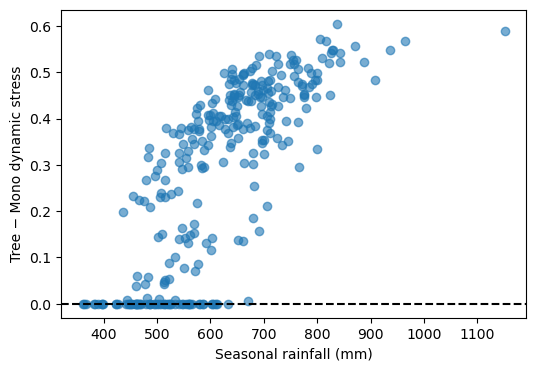

In [166]:
plt.figure(figsize=(6,4))

plt.scatter(
    df_compare["RF"],
    df_compare["delta_stress"],
    alpha=0.6
)

plt.axhline(0, linestyle="--", color="k")

plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Tree − Mono dynamic stress")

plt.show()


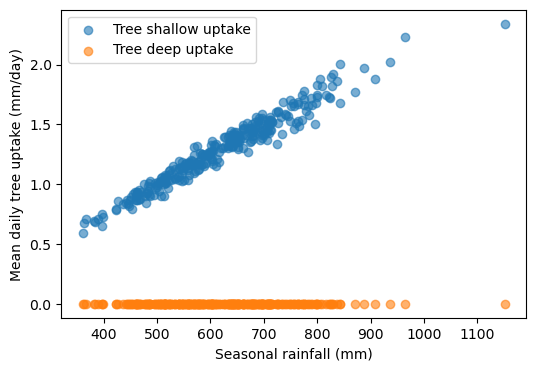

In [167]:
mean_top = []
mean_deep = []

for out in outs_t:
    mean_top.append(out["T_tree_top"].mean())
    mean_deep.append(out["T_tree_deep"].mean())

mean_top = np.array(mean_top)
mean_deep = np.array(mean_deep)
RF = df_tree["RF"].values

plt.figure(figsize=(6,4))
plt.scatter(RF, mean_top, alpha=0.6, label="Tree shallow uptake")
plt.scatter(RF, mean_deep, alpha=0.6, label="Tree deep uptake")
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Mean daily tree uptake (mm/day)")
plt.legend()
plt.show()


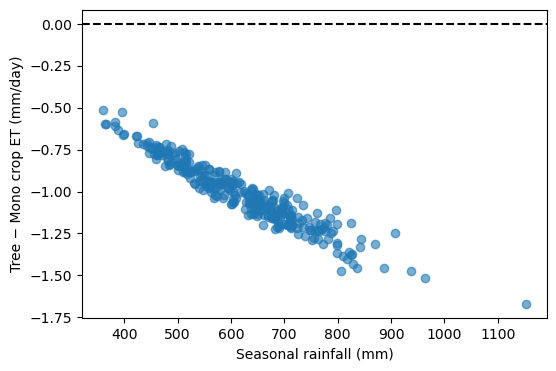

In [156]:
mean_ET_crop_tree = np.array([out["ET_crop"].mean() for out in outs_t])
mean_ET_crop_mono = np.array([out["ET"].mean() for out in outs_m])

delta_ET_crop = mean_ET_crop_tree - mean_ET_crop_mono
plt.figure(figsize=(6,4))
plt.scatter(RF, delta_ET_crop, alpha=0.6)
plt.axhline(0, linestyle="--", color="k")
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Tree − Mono crop ET (mm/day)")
plt.show()


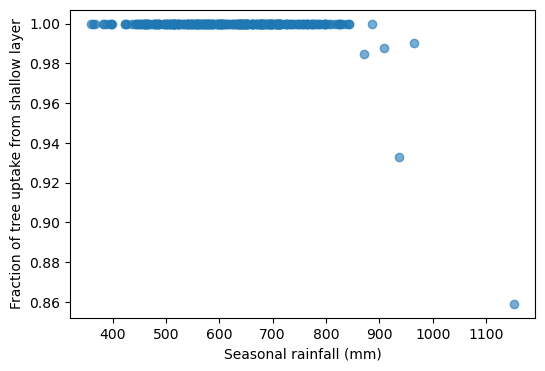

In [157]:
frac_shallow = mean_top / (mean_top + mean_deep + 1e-9)
plt.figure(figsize=(6,4))
plt.scatter(RF, frac_shallow, alpha=0.6)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Fraction of tree uptake from shallow layer")
plt.show()


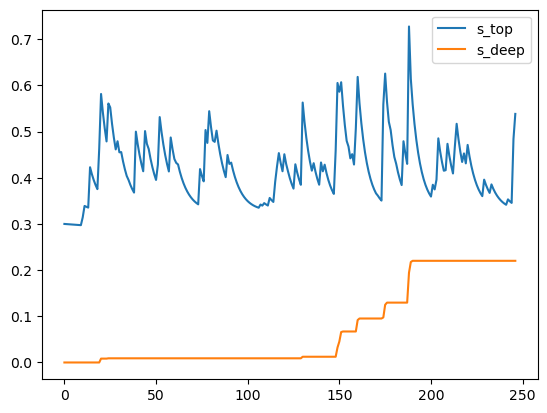

In [137]:
wet_index = np.argmax(RF)
out = outs_t[wet_index]

plt.plot(out["s_top"], label="s_top")
plt.plot(out["s_deep"], label="s_deep")
plt.legend()
plt.show()


## Rainfall regime study

| Regime | Expected pattern |
|--------|------------------|
| Few intense | frac\_shallow ≈ 1, deep ≈ 0 |
| Baseline | some deep activation |
| Many small | frac\_shallow ↓, deep ↑ |

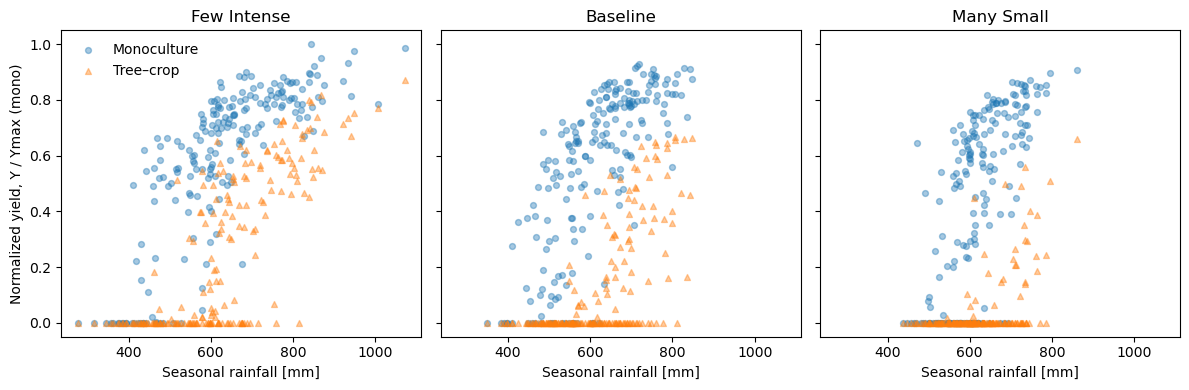

In [152]:
rain_regimes = {
    "few_intense": dict(alpha_scale=1.5, lambda_scale=0.67),
    "baseline":    dict(alpha_scale=1.0, lambda_scale=1.0),
    "many_small":  dict(alpha_scale=0.67, lambda_scale=1.5),
}

def simulate_systems_by_regime(n_sims, *, lgp=180, texture="loam", seed=123):
    rng = np.random.default_rng(seed)
    default_climate = Climate()

    rows = []

    for regime, scales in rain_regimes.items():
        for i in range(n_sims):
            np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

            climate = Climate(
                alpha_r=[a * scales["alpha_scale"] for a in default_climate.alpha_r],
                lambda_r=[l * scales["lambda_scale"] for l in default_climate.lambda_r],
                ET_max=default_climate.ET_max
            )

            # monoculture
            crop_m, out_m = run_one_season(
                CropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp
            )
            a, d, y, rf = season_metrics(crop_m, out_m, lgp)
            rows.append(dict(
                Regime=regime, System="Mono", RF=rf, Yield=y
            ))

            # tree–crop
            crop_t, out_t = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp,
                tree_params=tree_params
            )
            a, d, y, rf = season_metrics(crop_t, out_t, lgp)
            rows.append(dict(
                Regime=regime, System="TreeCrop", RF=rf, Yield=y
            ))

    return pd.DataFrame(rows)


df = simulate_systems_by_regime(n_sims=200, lgp=180, seed=42)
df_mono = df[df.System == "Mono"].copy()
df_tree = df[df.System == "TreeCrop"].copy()
Ymax = df_mono["Yield"].max()
df_mono["Yield_norm"] = df_mono["Yield"] / Ymax
df_tree["Yield_norm"] = df_tree["Yield"] / Ymax


fig, axes = plt.subplots(
    1, 3, figsize=(12,4),
    sharex=True, sharey=True
)

regimes = ["few_intense", "baseline", "many_small"]

for ax, regime in zip(axes, regimes):
    m = (df_mono.Regime == regime)
    t = (df_tree.Regime == regime)

    ax.scatter(
        df_mono.loc[m, "RF"],
        df_mono.loc[m, "Yield_norm"],
        s=18, alpha=0.4,
        marker="o", label="Monoculture"
    )

    ax.scatter(
        df_tree.loc[t, "RF"],
        df_tree.loc[t, "Yield_norm"],
        s=18, alpha=0.4,
        marker="^", label="Tree–crop"
    )

    ax.set_title(regime.replace("_", " ").title())
    ax.set_xlabel("Seasonal rainfall [mm]")

axes[0].set_ylabel("Normalized yield, Y / Ymax (mono)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()



## Tree parameter sensitivity

In [31]:
baseline_tree = dict(
    Zr=1500,
    T_MAX=1.0,
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
    kc=1.0
)
param_grid = {
    "T_MAX": [0.5, 1.0, 2.0],
    "Zr":    [800, 1500, 2500],
    "kc":    [0.5, 1.0, 1.5],
}
def generate_climates(n_sims, seed=42):
    rng = np.random.default_rng(seed)
    climates = []
    for _ in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1))
        climates.append(Climate())
    return climates

def stress_sensitivity(param_name, values, climates, lgp=180):

    results = []

    for val in values:

        tree_params = baseline_tree.copy()
        tree_params[param_name] = val

        stresses = []

        for climate in climates:

            crop, out = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture="loam", lgp=lgp,
                tree_params=tree_params
            )

            a, d, y, rf = season_metrics(crop, out, lgp)
            stresses.append(d)

        results.append({
            "param": param_name,
            "value": val,
            "mean_stress": np.mean(stresses),
            "std_stress": np.std(stresses)
        })

    return pd.DataFrame(results)

climates = generate_climates(n_sims=100, seed=42)

df_Tmax = stress_sensitivity("T_MAX", param_grid["T_MAX"], climates)
df_Zr   = stress_sensitivity("Zr", param_grid["Zr"], climates)
df_kc   = stress_sensitivity("kc", param_grid["kc"], climates)



In [32]:
df_kc

,param,value,mean_stress,std_stress
0,kc,0.5,0.687376,0.303748
1,kc,1.0,0.829663,0.231672
2,kc,1.5,0.929607,0.157455
